# Libraries

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Text preprocessing
import re
import string

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [6]:
import os

os.listdir('../data/raw')

['enron_spam_data.csv']

In [8]:
data = pd.read_csv("../data/raw/enron_spam_data.csv")

data.head()

,Unnamed: 0,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14


# Data Info

In [11]:
print("Dataset Shape:", data.shape)

print("Columns:", data.columns)

data.info()

Dataset Shape: (33716, 5)
Columns: Index(['Unnamed: 0', 'Subject', 'Message', 'Spam/Ham', 'Date'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  33716 non-null  int64 
 1   Subject     33716 non-null  object
 2   Message     33664 non-null  object
 3   Spam/Ham    33716 non-null  object
 4   Date        33716 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.3+ MB


# Class Distribution

In [14]:
# Count spam and ham emails
data['Spam/Ham'].value_counts()

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64

# DATA CLEANING

In [17]:
# Remove unnecessary columns
data = data.drop(columns=['Unnamed: 0', 'Date'])

# Check dataset
data.head()

,Subject,Message,Spam/Ham
0,christmas tree farm pictures,NaN,ham
1,"vastar resources , inc .","gary , production from the high island larger ...",ham
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham
3,re : issue,fyi - see note below - already done .\nstella\...,ham
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham


In [19]:
# Check missing values
data.isnull().sum()

Subject      0
Message     52
Spam/Ham     0
dtype: int64

In [21]:
# Remove rows with missing message
data = data.dropna()

print("New Dataset Shape:", data.shape)

New Dataset Shape: (33664, 3)


In [23]:
data = data.rename(columns={
    'Spam/Ham': 'label',
    'Subject': 'subject',
    'Message': 'message'
})

data.head()

,subject,message,label
1,"vastar resources , inc .","gary , production from the high island larger ...",ham
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham
3,re : issue,fyi - see note below - already done .\nstella\...,ham
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham
5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham


In [25]:
data['text'] = data['subject'] + " " + data['message']

data.head()

,subject,message,label,text
1,"vastar resources , inc .","gary , production from the high island larger ...",ham,"vastar resources , inc . gary , production fro..."
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,calpine daily gas nomination - calpine daily g...
3,re : issue,fyi - see note below - already done .\nstella\...,ham,re : issue fyi - see note below - already done...
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,meter 7268 nov allocation fyi .\n- - - - - - -...
5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,"mcmullen gas for 11 / 99 jackie ,\nsince the i..."


# Text Preprocessing

## Machine learning models cannot understand raw text, so we must clean the text first.

## We will do the following preprocessing steps:

### Convert text to lowercase
### Remove punctuation
### Remove numbers
### Remove stopwords (words like the, is, and)
### Tokenize the text

In [28]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [29]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [34]:
stop_words = set(stopwords.words('english'))

# Text Cleaning

In [37]:
def clean_text(text):
    
    # convert to lowercase
    text = text.lower()
    
    # remove numbers
    text = re.sub(r'\d+', '', text)
    
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # tokenize words
    tokens = word_tokenize(text)
    
    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

In [39]:
data['clean_text'] = data['text'].apply(clean_text)


In [40]:

data[['text','clean_text']].head()

,text,clean_text
1,"vastar resources , inc . gary , production fro...",vastar resources inc gary production high isla...
2,calpine daily gas nomination - calpine daily g...,calpine daily gas nomination calpine daily gas...
3,re : issue fyi - see note below - already done...,issue fyi see note already done stella forward...
4,meter 7268 nov allocation fyi .\n- - - - - - -...,meter nov allocation fyi forwarded lauri allen...
5,"mcmullen gas for 11 / 99 jackie ,\nsince the i...",mcmullen gas jackie since inlet river plant sh...


In [41]:
data.columns

Index(['subject', 'message', 'label', 'text', 'clean_text'], dtype='object')

# Convert Text to Numerical Features (TF-IDF)
## Machine learning algorithms like:
### Naïve Bayes
### Logistic Regression
### SVM
## cannot understand text directly. So we convert the cleaned text into numerical vectors using TF-IDF (Term Frequency – Inverse Document Frequency).

### TF-IDF measures how important a word is in a document compared to the whole dataset.Words that appear frequently in spam emails (like free, win, prize) will get higher importance.

In [48]:
tfidf = TfidfVectorizer(max_features=5000)


## Convert Text to Features

In [51]:
X = tfidf.fit_transform(data['clean_text'])

In [57]:
y = data['label'].map({'spam':1, 'ham':0})

In [59]:
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (33664, 5000)
Target Shape: (33664,)


# Train/Test Split

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (26931, 5000)
Testing Data: (6733, 5000)


# 1. Naïve Bayes

In [65]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

MultinomialNB()

# Make Prediction

In [68]:
nb_pred = nb_model.predict(X_test)

# Evaluate the Model

In [78]:
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)

print("Accuracy:", nb_accuracy)
print("Precision:", nb_precision)
print("Recall:", nb_recall)

Accuracy: 0.9814347244913114
Precision: 0.9651713569239343
Recall: 1.0


# Confusion Matrix

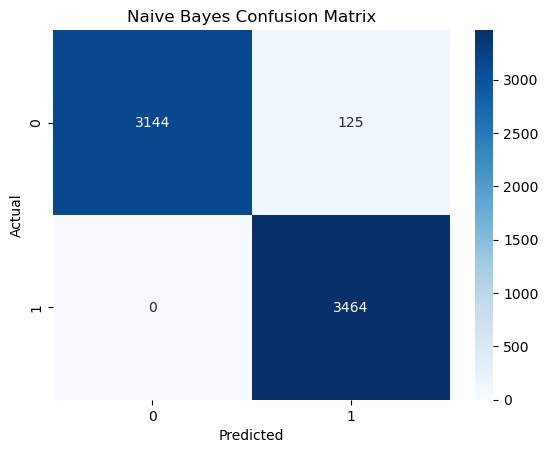

In [76]:
cm = confusion_matrix(y_test, nb_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.savefig("../results/naive_bayes_confusion_matrix.png")
plt.show()

# Performance Graph

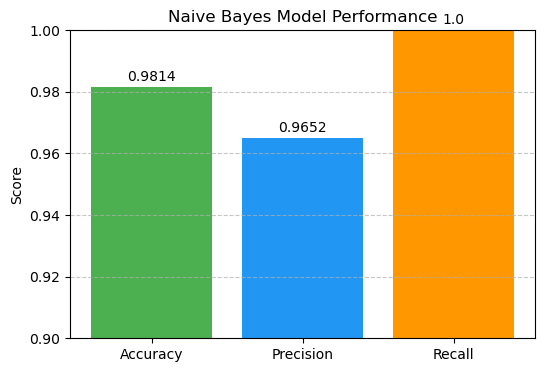

In [87]:
metrics = ['Accuracy', 'Precision', 'Recall']
values = [nb_accuracy, nb_precision, nb_recall]

plt.figure(figsize=(6,4))

colors = ['#4CAF50', '#2196F3', '#FF9800']   # green, blue, orange

bars = plt.bar(metrics, values, color=colors)

plt.title("Naive Bayes Model Performance")
plt.ylabel("Score")
plt.ylim(0.9, 1.0)

plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, round(yval,4), 
             ha='center', va='bottom')

plt.savefig("../results/naive_bayes_performance.png", bbox_inches='tight')

plt.show()

## Accuracy tells us:

### Out of all emails, how many were classified correctly.

## Precision tells us:

### Out of all emails predicted as spam, how many were actually spam.

## Recall tells us:

### Out of all actual spam emails, how many the model successfully detected.

# Report

In [89]:
report = classification_report(y_test, nb_pred)

print(report)

with open("../results/naive_bayes_report.txt", "w") as f:
    f.write(report)

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      3269
           1       0.97      1.00      0.98      3464

    accuracy                           0.98      6733
   macro avg       0.98      0.98      0.98      6733
weighted avg       0.98      0.98      0.98      6733



# Training vs Testing Accuracy

In [91]:
train_pred = nb_model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, nb_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9831421038951395
Testing Accuracy: 0.9814347244913114


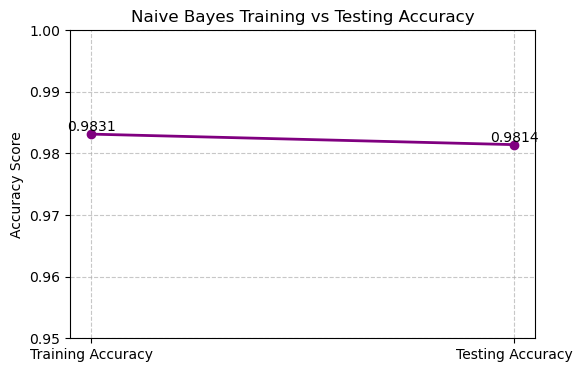

In [104]:
labels = ['Training Accuracy', 'Testing Accuracy']
values = [train_accuracy, test_accuracy]

plt.figure(figsize=(6,4))

plt.plot(labels, values, marker='o', linewidth=2,color="#800080")

plt.title("Naive Bayes Training vs Testing Accuracy")
plt.ylabel("Accuracy Score")
plt.ylim(0.95, 1.0)

plt.grid(True, linestyle='--', alpha=0.7)

# Add value labels
for i, v in enumerate(values):
    plt.text(i, v + 0.0005, round(v,4), ha='center')

plt.savefig("../results/naive_bayes_train_test_accuracy.png", bbox_inches='tight')

plt.show()

# 2. Logistic Regression Mode

In [109]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Make Prediction

In [112]:
lr_pred = lr_model.predict(X_test)

# Evaluate the Model

In [115]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)

print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)

Accuracy: 0.9989603445715134
Precision: 0.9979832901181216
Recall: 1.0


# Confusion Matrix

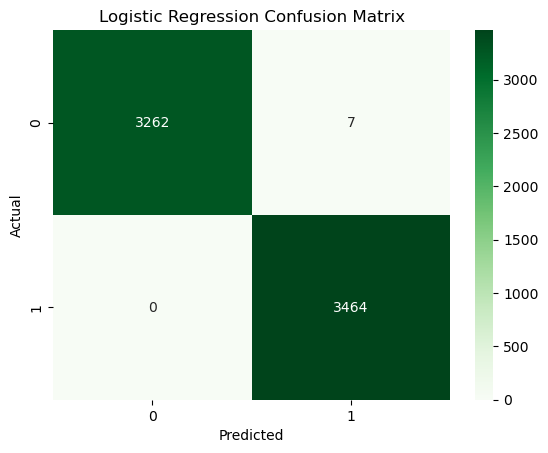

In [124]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure()

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.savefig("../results/logistic_regression_confusion_matrix.png")

plt.show()

# Performance Graph

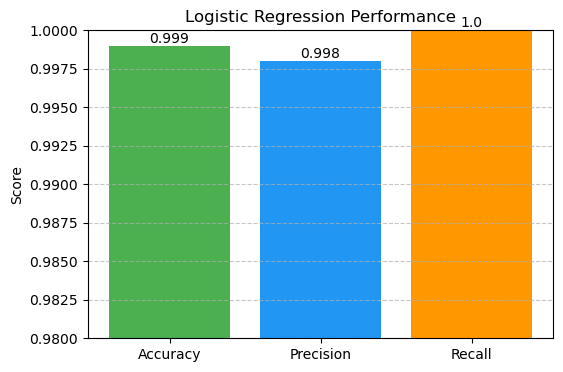

In [135]:
metrics = ['Accuracy', 'Precision', 'Recall']
values = [lr_accuracy, lr_precision, lr_recall]

plt.figure(figsize=(6,4))

colors = ['#4CAF50', '#2196F3', '#FF9800']

bars = plt.bar(metrics, values, color=colors)

plt.title("Logistic Regression Performance")
plt.ylabel("Score")
plt.ylim(0.98, 1.0)

plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0002, round(yval,4),
             ha='center')

plt.savefig("../results/logistic_regression_performance.png", bbox_inches='tight')

plt.show()

## Accuracy = Correct Predictions / Total Predictions
## Precision = True Spam / Predicted Spam
## Recall = True Spam / Actual Spam

# Report

In [139]:
lr_report = classification_report(y_test, lr_pred)

print(lr_report)

with open("../results/logistic_regression_report.txt", "w") as f:
    f.write(lr_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3269
           1       1.00      1.00      1.00      3464

    accuracy                           1.00      6733
   macro avg       1.00      1.00      1.00      6733
weighted avg       1.00      1.00      1.00      6733



# Training vs Testing Accuracy

In [142]:
lr_train_pred = lr_model.predict(X_train)

lr_train_accuracy = accuracy_score(y_train, lr_train_pred)
lr_test_accuracy = accuracy_score(y_test, lr_pred)

print("Training Accuracy:", lr_train_accuracy)
print("Testing Accuracy:", lr_test_accuracy)

Training Accuracy: 0.9989603059671011
Testing Accuracy: 0.9989603445715134


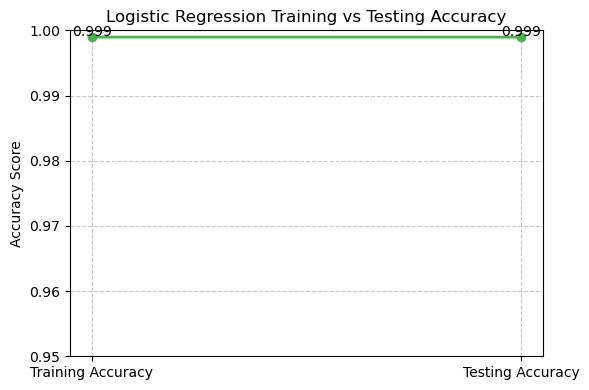

In [173]:
plt.figure(figsize=(6,4), dpi=100)

labels = ['Training Accuracy', 'Testing Accuracy']
values = [lr_train_accuracy, lr_test_accuracy]

plt.plot(labels, values, marker='o', linewidth=2,color = '#4CAF50')

plt.title("Logistic Regression Training vs Testing Accuracy")
plt.ylabel("Accuracy Score")
plt.ylim(0.95, 1.0)

plt.grid(True, linestyle='--', alpha=0.7)

for i, v in enumerate(values):
    plt.text(i, v + 0.0002, round(v,4), ha='center')

plt.tight_layout()

plt.savefig("../results/logistic_regression_train_test_accuracy.png")

plt.show()
plt.close()


# 3. SVM Model

In [153]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

LinearSVC()

# Make Prediction

In [158]:
svm_pred = svm_model.predict(X_test)

# Evaluate the Model

In [161]:
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)

print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)

Accuracy: 0.999108866775583
Precision: 0.9982708933717579
Recall: 1.0


# Confusion Matrix

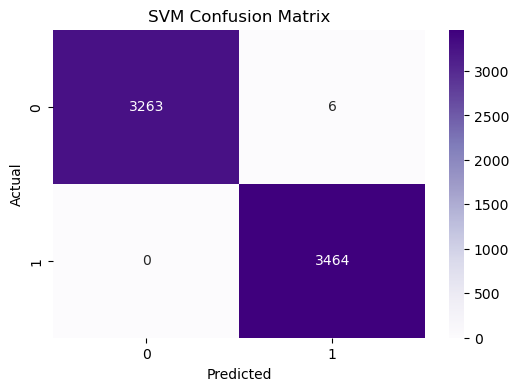

In [164]:
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.savefig("../results/svm_confusion_matrix.png", bbox_inches='tight')

plt.show()

# Performace Graph

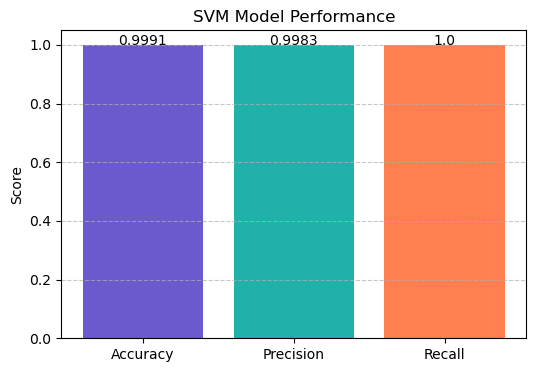

In [180]:
metrics = ['Accuracy', 'Precision', 'Recall']
values = [svm_accuracy, svm_precision, svm_recall]

plt.figure(figsize=(6,4))

colors = ['#6A5ACD', '#20B2AA', '#FF7F50']

bars = plt.bar(metrics, values, color=colors)

plt.title("SVM Model Performance")
plt.ylabel("Score")

plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0002, round(yval,4),
             ha='center')

plt.savefig("../results/svm_performance.png", bbox_inches='tight')

plt.show()

# Report

In [185]:
svm_report = classification_report(y_test, svm_pred)

print(svm_report)

with open("../results/svm_report.txt", "w") as f:
    f.write(svm_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3269
           1       1.00      1.00      1.00      3464

    accuracy                           1.00      6733
   macro avg       1.00      1.00      1.00      6733
weighted avg       1.00      1.00      1.00      6733



# Training vs Testing Accuracy

In [188]:
svm_train_pred = svm_model.predict(X_train)

svm_train_accuracy = accuracy_score(y_train, svm_train_pred)
svm_test_accuracy = accuracy_score(y_test, svm_pred)

print("Training Accuracy:", svm_train_accuracy)
print("Testing Accuracy:", svm_test_accuracy)

Training Accuracy: 0.9995172849132969
Testing Accuracy: 0.999108866775583


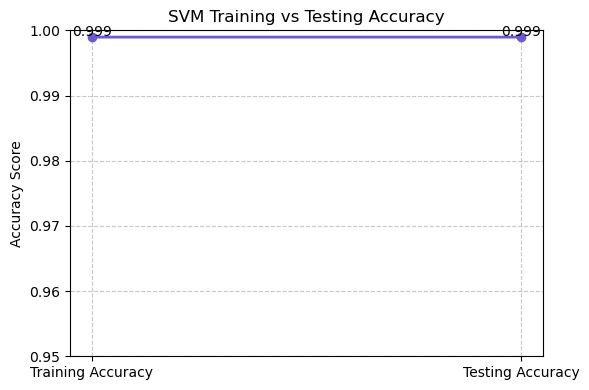

In [190]:
plt.figure(figsize=(6,4), dpi=100)

labels = ['Training Accuracy', 'Testing Accuracy']
values = [lr_train_accuracy, lr_test_accuracy]

plt.plot(labels, values, marker='o', linewidth=2,color = '#6A5ACD')

plt.title("SVM Training vs Testing Accuracy")
plt.ylabel("Accuracy Score")
plt.ylim(0.95, 1.0)

plt.grid(True, linestyle='--', alpha=0.7)

for i, v in enumerate(values):
    plt.text(i, v + 0.0002, round(v,4), ha='center')

plt.tight_layout()

plt.savefig("../results/svm_train_test_accuracy.png")

plt.show()
plt.close()


# Model Comparison Graph

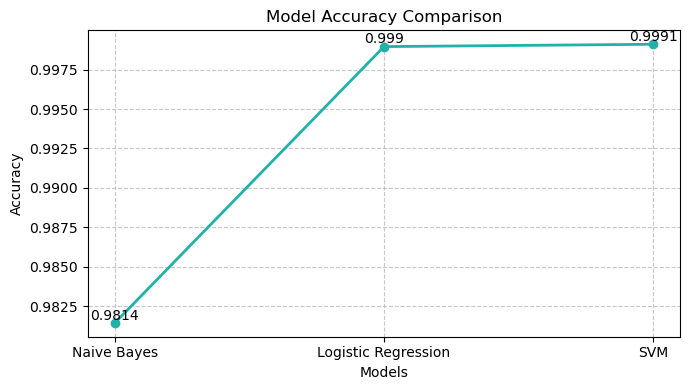

In [195]:
models = ['Naive Bayes', 'Logistic Regression', 'SVM']

accuracy_scores = [nb_accuracy, lr_accuracy, svm_accuracy]

plt.figure(figsize=(7,4), dpi=100)

plt.plot(models, accuracy_scores, marker='o', linewidth=2,color='#20B2AA')

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.grid(True, linestyle='--', alpha=0.7)

for i, v in enumerate(accuracy_scores):
    plt.text(i, v + 0.0002, round(v,4), ha='center')

plt.tight_layout()

plt.savefig("../results/model_accuracy_comparison.png")

plt.show()

# Saving the Final Model

In [198]:
import joblib

In [202]:
joblib.dump(nb_model, "../models/naive_bayes_model.pkl")

joblib.dump(lr_model, "../models/logistic_regression_model.pkl")

joblib.dump(svm_model, "../models/svm_model.pkl")

['../models/svm_model.pkl']

# Save TF-IDF Vectorizer
## The vectorizer must also be saved because the same vocabulary must be used during prediction.

In [205]:
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

# Spam Detection Function

In [239]:
def predict_spam(email_text):

    cleaned = clean_text(email_text)

    vector = tfidf.transform([cleaned])

    prediction = svm_model.predict(vector)

    if prediction[0] == 1:
        return "Spam Email!......"
    else:
        return "Not a Spam Email!......"

# Prediction

In [242]:
email = input("📧 Enter Email Content:")

prediction = predict_spam(email)

print("\n🔍 Spam Detection Result:",prediction)


📧 Enter Email Content: Hi John, let's schedule a meeting tomorrow morning.



🔍 Spam Detection Result: Not a Spam Email!......
